In [ ]:
import ast 
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import MultiLabelBinarizer

import librosa
import librosa.display
import soundfile as sf

from IPython.display import Markdown

from pathlib import Path
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.notebooks.eda import *
from birdclef_2026_ml.preprocess import *
from birdclef_2026_ml.paths import PATHS

init_notebook()

In [13]:
train = pd.read_parquet(PATHS['proc_train'])
taxonomy = pd.read_csv(PATHS['taxonomy'])
soundscapes = pd.read_parquet(PATHS['proc_soundscapes'])

In [ ]:
# Combine primary_label (str) and secondary_labels (list) into a single list for each row
def combine_labels(row):
    return [row["primary_label"]] + row["secondary_labels"]

ss_labels = soundscapes["primary_label_list"].explode()
df = train[["primary_label", "secondary_labels"]].copy()
df["all_labels"] = df.apply(combine_labels, axis=1)

In [59]:
# Build a sorted union of all unique labels from train and soundscapes
all_labels = pd.Index(df["all_labels"].explode().unique()).union(pd.Index(ss_labels)).sort_values()

mlb = MultiLabelBinarizer(classes=np.unique(all_labels))  # multi-hot encoding with consistent order
Y_train = mlb.fit_transform(df["all_labels"])

# Compute co-occurrence matrix for train
C_train = Y_train.T @ Y_train
np.fill_diagonal(C_train, 0)
row_sums = C_train.sum(axis=1, keepdims=True)
C_train = np.divide(C_train, row_sums, where=row_sums!=0)
C_train = np.nan_to_num(C_train, nan=0)

# Compute co-occurrence matrix for soundscapes
Y_soundscapes = mlb.transform(soundscapes["primary_label_list"])
C_soundscapes = Y_soundscapes.T @ Y_soundscapes
np.fill_diagonal(C_soundscapes, 0)
row_sums_sc = C_soundscapes.sum(axis=1, keepdims=True)
C_soundscapes = np.divide(C_soundscapes, row_sums_sc, where=row_sums_sc!=0)
C_soundscapes = np.nan_to_num(C_soundscapes, nan=0)

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_98433/2727474374.py:11: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  C_train = np.divide(C_train, row_sums, where=row_sums!=0)
/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_98433/2727474374.py:19: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  C_soundscapes = np.divide(C_soundscapes, row_sums_sc, where=row_sums_sc!=0)


<Axes: >

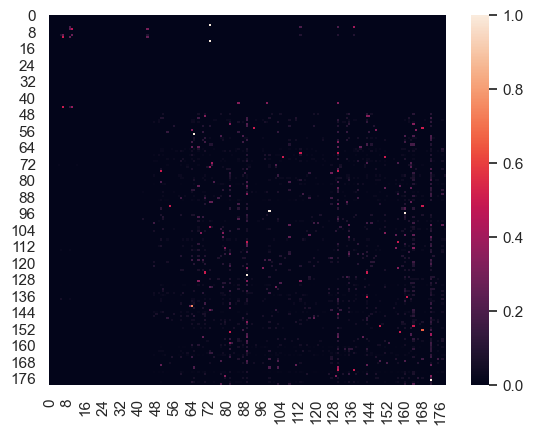

In [60]:
sns.heatmap(C_train)

<Axes: >

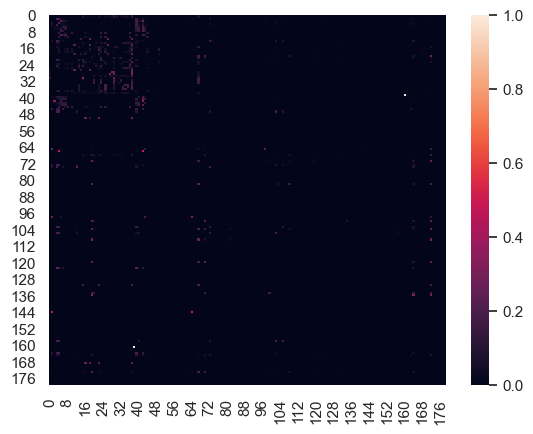

In [61]:
sns.heatmap(C_soundscapes)